In [3]:
import pymanopt
from pymanopt.manifolds.manifold import Manifold
from pymanopt import function
import numpy as np
from scipy.linalg import expm
from scipy.stats import special_ortho_group
from pymanopt.optimizers import SteepestDescent
from pymanopt.optimizers import TrustRegions
import matplotlib.pyplot as plt
from pymanopt.tools.diagnostics import check_gradient, check_hessian
from pymanopt import Problem, optimizers
from pymanopt.optimizers.optimizer import OptimizerResult
import time

from pymanopt.function import numpy as pymanopt_function
import matplotlib.pyplot as plt



class SpecialOrthogonalProductAnchored(Manifold):
    def __init__(self, d, m, anchor_indices, anchor_values,E,H,kappa1=1.0, kappa2=0.1, q=0.9):
        self._d = d
        self._m = m
        self._H=H
        self._E=E
        self._anchors = anchor_indices
        self._anchor_values = anchor_values
        self._non_anchors = [i for i in range(m) if i not in anchor_indices]
        self._triu_indices = np.triu_indices(d, k=1)
        self._tangent_dim = d*(d-1)//2
        self._kappa1=kappa1
        self._kappa2=kappa2
        self._q=q

        # Dimension is (m - |anchors|) * dim(SO(d))
        dim_SO = d * (d - 1) // 2
        self._dimension = (m - len(anchor_indices)) * dim_SO
        self._name = "SpecialOrthogonalProductAnchored"
        
        super().__init__("Anchored SO(d)^m", self._dimension)

        self._c1 = np.exp(-d*kappa1) * self._compute_cd(kappa1)
        self._c2 = np.exp(-d*kappa2) * self._compute_cd(kappa2)

    def inner_product(self, X, Omega, Psi):
        ip = 0.0
        for i in self._non_anchors:
            ip += 2.0 * np.dot(Omega[i].T, Psi[i])
        return ip   

    def norm(self,X, Omega):
        return np.sqrt(self.inner_product(X, Omega, Omega))
    
    def _unskew(self, omega_flat):
        """Convert compressed tangent vector to full skew-symmetric matrix."""
        Omega = np.zeros((self._d, self._d))
        Omega[self._triu_indices] = omega_flat
        Omega.T[self._triu_indices] = -omega_flat
        return Omega
    
    def _skew(self, Omega):
        """Extract upper triangular elements from skew-symmetric matrix."""
        return Omega[self._triu_indices]
    

    @property
    def typical_dist(self):
        return 1

    def projection(self, X, Z):
        """Project ambient vector Z to tangent space, returning compressed skew-symmetric vectors."""
        P = np.zeros((self._m, self._tangent_dim))  # Allocate space for compressed vectors
        
        for i in self._non_anchors:
            # Compute skew-symmetric part of XᵢᵀZᵢ
            skew_part = 0.5 * (X[i].T @ Z[i] - Z[i].T @ X[i])
            
            # Extract upper triangular elements (k=1 excludes diagonal)
            P[i] = skew_part[self._triu_indices]
        
        return P

    def dim(self):
        return self._dimension
    
    def euclidean_to_riemannian_gradient(self, x, egrad):
        return self.projection(x,egrad)



    def retraction(self, X, Omega):
        R = np.zeros_like(X)
        for i in range(self._m):
            if i in self._anchors:
                R[i] = X[i]  # Anchored points don't move
            else:
                Omega_i = self._unskew(Omega[i])
                R[i] = X[i] @ expm(Omega_i)
        return R

    def random_point(self):
        X = np.zeros((self._m, self._d, self._d))
        for i in range(self._m):
            if i in self._anchors:
                X[i] = self._anchor_values[i]
            else:
                X[i] = special_ortho_group.rvs(self._d)
        return X

    def random_tangent_vector(self, X):
        return self.projection(X,self.random_point())

    def zero_vector(self, X):
        return np.zeros((self._m, self._d, self._d))
    
    def _compute_cd(self, kappa):
        """Compute the normalizing constant c_d(kappa) for SO(d) Langevin distribution"""
        if kappa == 0:
            return 1.0  # Uniform distribution case
        if self._d == 2:
            return 2 * np.pi * iv(0, kappa)
        elif self._d == 3:
            return 4 * np.pi * (np.sinh(kappa) / kappa)
        else:
            # For higher dimensions, we'd need a more general approach
            raise NotImplementedError("Normalizing constant only implemented for d=2,3")


Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


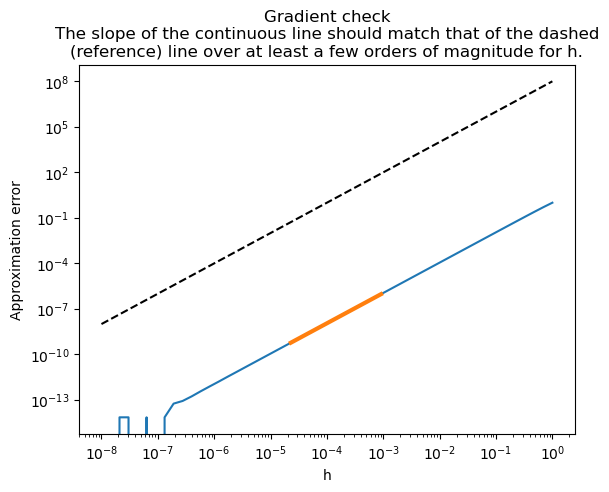

Pymanopt was unable to verify that the gradient is indeed a tangent vector since SpecialOrthogonalProductAnchored does not provide a 'to_tangent_space' implementation.
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +5.3094419387545649e+01    6.23732940e+00    
   2         +4.7609433086430556e+01    5.15714719e+00    
   3         +4.1680537430694244e+01    7.94253814e+00    
   4         +3.2901272806126748e+01    8.34289683e+00    
   5         +2.6103587275834318e+01    5.81116499e+00    
   6         +2.4460994266633374e+01    4.19129232e+00    
   7         +2.3487384765559501e+01    2.93482070e+00    
   8         +2.2921581223158963e+01    3.11293045e+00    
   9         +2.2107198460893500e+01    3.59442049e+00    
  10         +2.0758922067079901e+01    4.46139907e+00    
  11         +1.9053239159740443e+01    5.57768136e+00    
  12         +1.6945113557547103e+01    4.90042096e

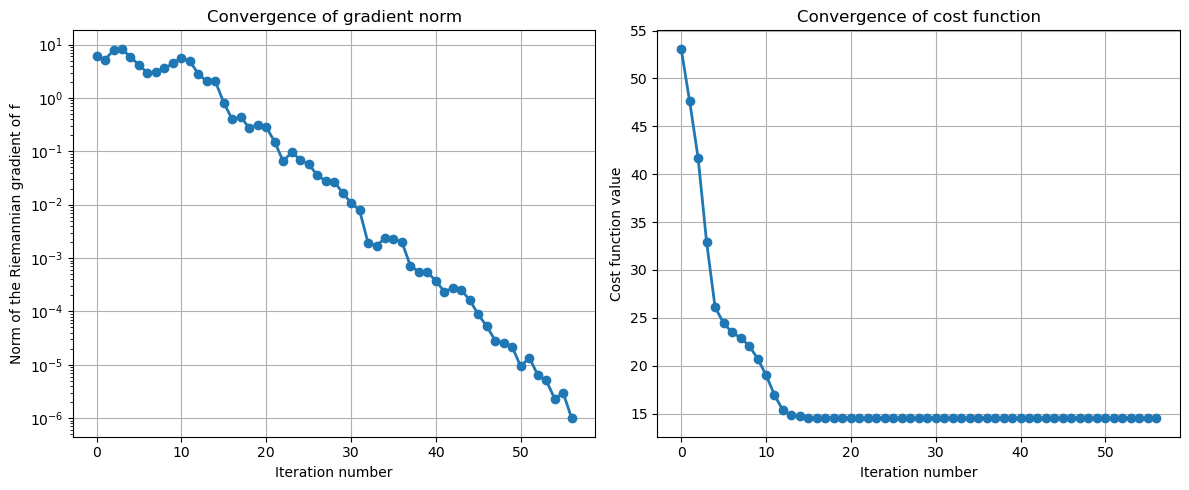

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


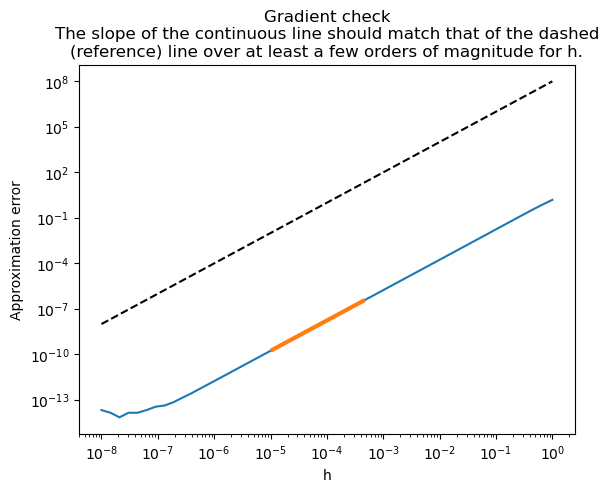

Pymanopt was unable to verify that the gradient is indeed a tangent vector since SpecialOrthogonalProductAnchored does not provide a 'to_tangent_space' implementation.
Hessian check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


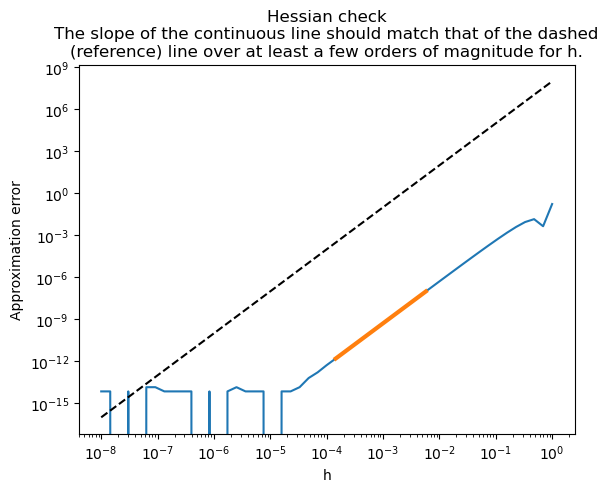

Pymanopt was unable to verify that the Hessian operator indeed yields a tangent vector since SpecialOrthogonalProductAnchored does not provide a 'to_tangent_space' implementation.

The norm of the residual between H[a*d1 + b*d2] and a*H[d1] + b*H[d2] should be very close to 0: 1.39553e-15.
If it is far from 0, then the Hessian is not a linear operator.

The difference <d1, H[d2]> - <H[d1], d2> should be close to zero: -4.88499 - -4.88499 = 1.77636e-15.
If it is far from 0 then the Hessian is not a symmetric operator.
14.52070203147437


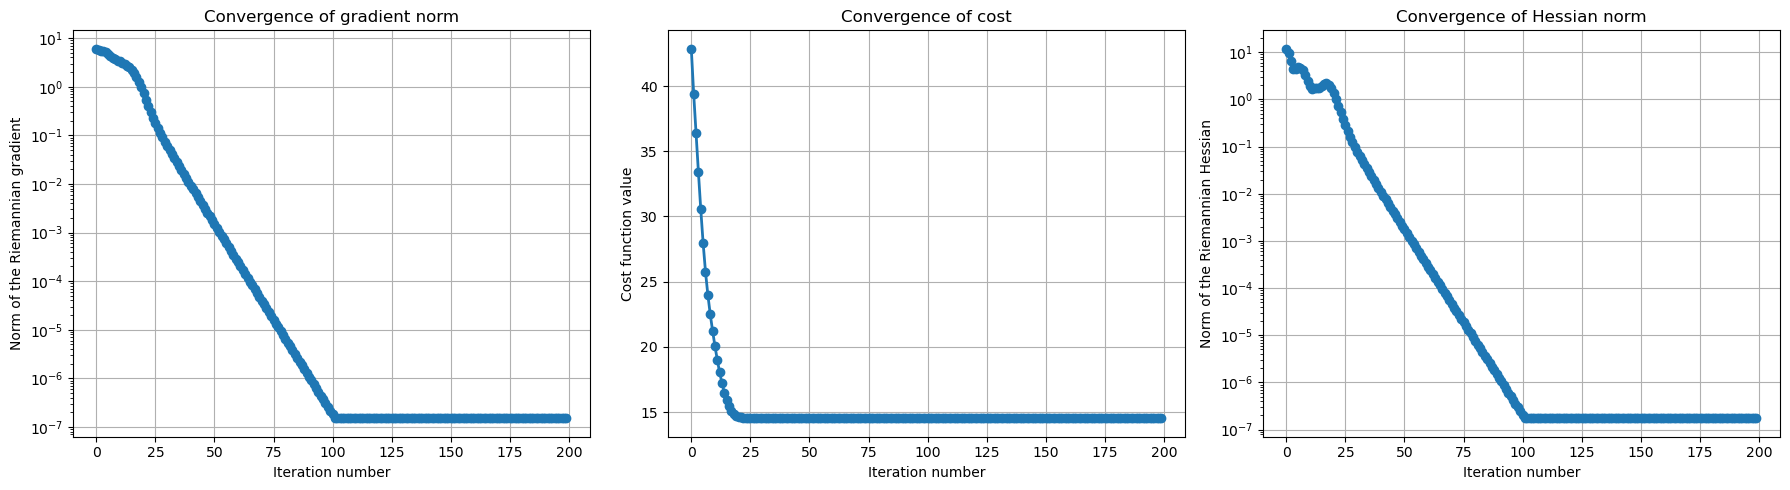

In [5]:
# Problem setup
d = 3 #warning d<3 because else we cannot define easily the constant C_\kappa
m = 5
anchor_indices = [0]
anchor_values = {0: np.eye(d)}
E = {i: [j for j in range(m) if j != i] for i in range(m)}
H = {}

# Generate synthetic measurements
for i in range(m):
    for j in range(i+1, m):
        R_true_i = special_ortho_group.rvs(d)
        R_true_j = special_ortho_group.rvs(d)
        Z_ij = special_ortho_group.rvs(d)
        H_ij = R_true_i @ Z_ij @ R_true_j.T
        H[(i,j)] = H_ij
        H[(j,i)] = H_ij.T

# Create manifold instance
manifold = SpecialOrthogonalProductAnchored(d, m, anchor_indices, anchor_values, E, H)

@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]    
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))

            
            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim)) 
    
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)
            
            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2
            
            alpha_ij = (manifold._q * manifold._kappa1 * p1 + 
                        (1 - manifold._q) * manifold._kappa2 * p2) / p
            
            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T - 
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))

    
    # Flatten grad into 1D to limit storage
    return -grad


problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

check_gradient(problem)

optimizer=optimizers.SteepestDescent(log_verbosity=2)
result=optimizer.run(problem)   
grad_norms = optimizer._log["iterations"]["gradient_norm"]
cost_values = optimizer._log["iterations"]["cost"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function")
plt.grid(True)

plt.tight_layout()
plt.show()


@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim)) 
    
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2
            


            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))
            
            U_j = X_j.dot(manifold._unskew(U[j]))
            
            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)
            
            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))
            

            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term
            
            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i + 
                            U_i @ X_j.T @ H_ji @ X_i - 
                            X_i @ U_i.T @ H_ij @ X_j - 
                            H_ij @ X_j @ U_i.T @ X_i)
            
            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
    return(-H)
    

problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)

check_gradient(problem)  #Verify gradient correctness

check_hessian(problem)


from numpy.linalg import norm
import matplotlib.pyplot as plt

hess_norms = []

# Custom optimizer loop to store hessian norms
optimizer = optimizers.SteepestDescent(log_verbosity=2)
x = problem.manifold.random_point()

if optimizer._log is None:
    optimizer._log = {}

optimizer._log["iterations"] = {"gradient_norm": [], "cost": []}

for i in range(200):  # Or until convergence
    grad = problem.riemannian_gradient(x)
    hess = problem.riemannian_hessian(x, grad)
    
    grad_norm = problem.manifold.norm(x, grad)
    cost_value = problem.cost(x)
    hess_norm = norm(hess)  # Frobenius norm of the Hessian (as a linear operator)

    optimizer._log["iterations"]["gradient_norm"].append(grad_norm)
    optimizer._log["iterations"]["cost"].append(cost_value)
    hess_norms.append(hess_norm)

    # Gradient descent step
    step = problem.manifold.retraction(x, -0.1 * grad)
    if i>100:
        step = problem.manifold.retraction(x, -0.1/np.exp(i) * grad)  # Fixed step size or use line search
    x = step
print(problem.cost(x))
# Plotting all
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.semilogy(optimizer._log["iterations"]["gradient_norm"], '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(optimizer._log["iterations"]["cost"], '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.semilogy(hess_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian Hessian")
plt.title("Convergence of Hessian norm")
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
from scipy.io import loadmat
import numpy as np


def matlab_to_python(x):
    """Converts Matlab scalars, vectors or matrices into Python format."""
    if isinstance(x, np.ndarray):
        if x.size == 1:
            return x.item()
        else:
            return x
    return x

def matstruct_to_dict(matobj):
    """Converts recursively a MATLAB struct into Python dictionary"""
    result = {}
    if not hasattr(matobj, '_fieldnames'):
        return matobj
    for field in matobj._fieldnames:
        val = getattr(matobj, field)
        if isinstance(val, np.ndarray) and val.dtype.names:
            result[field] = [matstruct_to_dict(v) for v in val]
        elif hasattr(val, '_fieldnames'):
            result[field] = matstruct_to_dict(val)
        else:
            result[field] = matlab_to_python(val)
    return result

def parse_matlab_data(raw_data):
    """
    Takes a dictionary from scipy.io.loadmat and returns the converted variables.
    
    Args:
        raw_data (dict): Result from loadmat()

    Returns:
        dict: Python dictionary with the converted variables + struct 'problem' if present
    """
    data = {}
    keys = ['A', 'ERp', 'H', 'I', 'J', 'kappa1', 'kappa2', 'm', 'M', 'n', 'N', 'p', 'Ra', 'Rtrue', 'Z']

    for key in keys:
        if key in raw_data:
            data[key] = matlab_to_python(raw_data[key])
        else:
            print(f" Variable {key} not found in the .mat file.")

    for key in ['I', 'J', 'A']:
        if key in data:
            data[key] = np.atleast_1d(np.squeeze(data[key])).astype(int) - 1

    if 'Ra' in data:
        Ra = data['Ra']
        if Ra.ndim == 2: # if it is (dxd) reshape as dxdx1
            d = Ra.shape[0]
            Ra = Ra[:, :, np.newaxis]
            data['Ra'] = Ra

    # Deal with the structure 'problem'
    if 'problem' in raw_data:
        try:
            data['problem'] = matstruct_to_dict(raw_data['problem'])
        except Exception as e:
            print(f" Error during the conversion of the structure 'problem': {e}")

    return data

raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


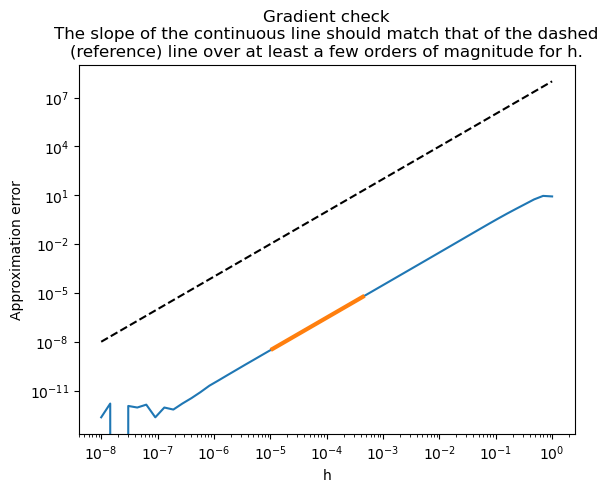

Pymanopt was unable to verify that the gradient is indeed a tangent vector since SpecialOrthogonalProductAnchored does not provide a 'to_tangent_space' implementation.
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +1.2830448649022894e+03    3.01132132e+01    
   2         +1.2563638543046627e+03    2.82571351e+01    
   3         +1.2441803573921252e+03    5.44974307e+01    
   4         +1.2005310615760770e+03    4.02499602e+01    
   5         +1.1894097380791816e+03    4.49987536e+01    
   6         +1.1616701709757933e+03    1.96753757e+01    
   7         +1.1541013741781971e+03    3.58860392e+01    
   8         +1.1425600192882121e+03    2.32730119e+01    
   9         +1.1369970875639729e+03    1.42101833e+01    
  10         +1.1346168397979109e+03    1.18257722e+01    
  11         +1.1338979516125028e+03    1.58318831e+01    
  12         +1.1319864186608620e+03    7.79668600e

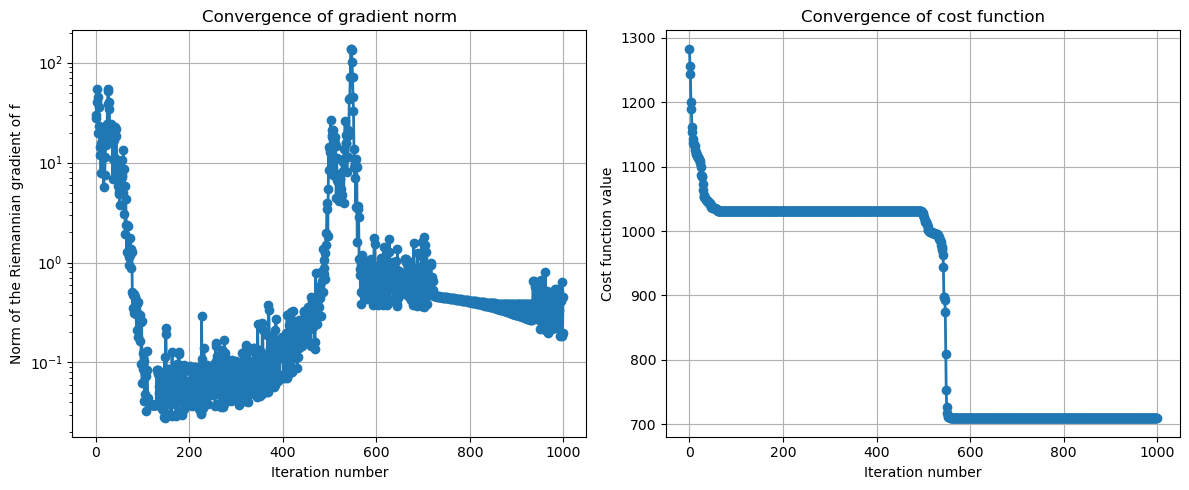

In [9]:
# Question 16
from pymanopt.optimizers import SteepestDescent
from collections import defaultdict
import numpy as np

raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i) 
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T

# Construct manifold with the values from data
manifold = SpecialOrthogonalProductAnchored(data['n'], data['N'], [data['A']], data['Ra'], E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])

# Define the problem
problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

# Solve the problem
np.random.seed(2)

check_gradient(problem)

optimizer=optimizers.SteepestDescent(log_verbosity=2)
result=optimizer.run(problem)
grad_norms = optimizer._log["iterations"]["gradient_norm"]
cost_values = optimizer._log["iterations"]["cost"]

# Plot the gradient norm and the cost function value
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function")
plt.grid(True)

plt.tight_layout()
plt.show()

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +1.2863819323296473e+03    2.64821842e+01    
   2         +1.2566963596950050e+03    3.09102847e+01    
   3         +1.2295450330347358e+03    2.73028088e+01    
   4         +1.2231676813269598e+03    4.57864506e+01    
   5         +1.2021750496941549e+03    2.87673279e+01    
   6         +1.1951550479861978e+03    3.81187549e+01    
   7         +1.1780105904387044e+03    1.88563595e+01    
   8         +1.1682994306396513e+03    1.89499157e+01    
   9         +1.1648299268912176e+03    1.60527797e+01    
  10         +1.1618914151189203e+03    1.67155150e+01    
  11         +1.1582964604272381e+03    2.68147581e+01    
  12         +1.1510551910452764e+03    1.74231650e+01    
  13         +1.1468768940456607e+03    5.26876918e+01    
  14         +1.1315899435100057e+03    4.30198456e+01    
  15         +1.1166720922888785e+03    4.

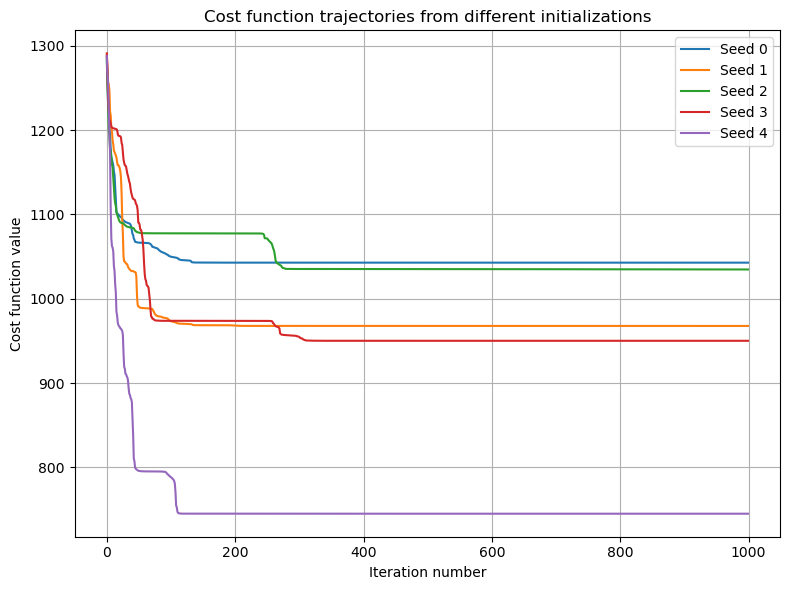

In [11]:
# Question 16 bis
# We further compare the final cost function values for different initializations and how the costs evolve for each initialization
import numpy as np
import matplotlib.pyplot as plt

final_costs = []
all_costs = []

for seed in range(5):
    np.random.seed(seed)
    x0 = manifold.random_point()
    result = optimizer.run(problem, initial_point=x0)
    
    # Log cost function values during the optimization
    costs = optimizer._log["iterations"]["cost"]
    all_costs.append(costs)
    
    final_costs.append(result.cost)

# Print final costs
print("Final cost values for each initialization:")
print(final_costs)

# Plot the cost trajectories
plt.figure(figsize=(8, 6))
for idx, costs in enumerate(all_costs):
    plt.plot(costs, label=f'Seed {idx}')
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Cost function trajectories from different initializations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Question 20
import numpy as np
from scipy.sparse.linalg import eigsh
from scipy.io import loadmat
from collections import defaultdict

def solve_relaxation(W1, D1, d):
    # Compute the generalized eigenvalues and eigenvectors from W1 v = lambda D1 v
    vals, vecs = eigsh(W1, d, D1, which='LA')
    
    # Reverse order of eigenvalues to have them from largest to smallest, adapt eigenvectors accordingly
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    # Normalize columns of Y so that Y^T D1 Y = Tr(D) * I_d
    tr_D1 = np.trace(D1)
    tr_D = tr_D1 / d
    norm_factor = np.sqrt(tr_D)
    Y_normalized = vecs * norm_factor

    # Write Y as (m, d, d) tensor
    m = W1.shape[0] // d
    Y = Y_normalized.reshape((m, d, d))

    # Compute the maximum value
    max_value = tr_D * np.sum(vals)
    
    return Y, max_value


# Test the above function on the generated data from question 16
# Load the data and format it
raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i) 
E = dict(E)
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T
    
# Extract d and m and construct W1 and D1
d = data['n']
m = data['N']
W1 = np.zeros((d*m, d*m))
for i in range(m):
    for j in E.get(i, []):
        if (i, j) in H:
            block_i = slice(i*d, (i+1)*d)
            block_j = slice(j*d, (j+1)*d)
            W1[block_i, block_j] = H[(i, j)]
degrees = data['problem']['d']
D = np.diag(degrees)
D1 = np.kron(D, np.eye(d))

# Solve the relaxation problem (8)
Y, opt_val = solve_relaxation(W1, D1, d)
print("\nOptimal Y (argmax of the relaxation):")
print(Y)
print("\nOptimal value (maximum of the relaxation):")
print(opt_val)

# Check that the constraint is satisfied
def check_constraint(Y, d, m, D):
    Y_flat = Y.reshape(m*d, d)
    D1 = np.kron(D, np.eye(d))

    if not np.allclose(Y_flat.T @ D1 @ Y_flat, np.trace(D)*np.eye(d), atol=1e-6):
        print(f"The constraint is not satisfied.")
        return False

    print("\nThe constraint is satisfied.")
    return True
check_constraint(Y, d, m, D)


Optimal Y (argmax of the relaxation):
[[[ 0.61713072 -0.81569934  0.3479714 ]
  [ 0.81094341  0.3690096  -0.52918892]
  [-0.11764913 -0.55744067 -0.80494898]]

 [[-0.30176133  0.33649451  1.00690939]
  [ 0.78016823  0.62800841 -0.06598243]
  [ 0.64874079 -0.66815978  0.45872758]]

 [[ 0.15841821  1.08028612 -0.23264743]
  [ 1.00972462 -0.10241744  0.35400789]
  [-0.2624418   0.27129916  1.06224496]]

 [[ 0.05805482  0.99626954 -0.1391037 ]
  [-0.8545228  -0.07587022  0.16758556]
  [-0.26022895  0.05016518 -0.97671949]]

 [[-0.73162083 -0.89638328 -0.09470134]
  [-0.79838562  0.72481976 -0.23812718]
  [-0.16697461  0.14709689  1.10202395]]

 [[ 0.33516259 -0.88413857  0.48386437]
  [-0.73677599 -0.04191184  0.70072558]
  [ 0.63004638  0.72482238  0.56233414]]

 [[-0.44029993  0.56234406  0.46103958]
  [ 0.884218    0.2823236   0.5521624 ]
  [-0.07050528 -0.66290197  0.4508738 ]]

 [[ 0.76307636  0.11553423 -0.527889  ]
  [ 0.34131805  0.39247855  0.56514674]
  [-0.18683373  0.81728511 

True

In [15]:
# Question 23
import numpy as np
from numpy.linalg import svd, det

# Function performing the projection onto SO(d)
def projection_SO(S):
    U, _, Vt = svd(S)
    determinant = det(U @ Vt)
    P = np.eye(U.shape[0])
    P[-1, -1] = np.sign(determinant)
    return U @ P @ Vt

def initial_guess(deg, m, d, E, H, A, Ra):
    # Inputs:
    #    deg: vector of degrees
    #    m: number of rotations to synchronize
    #    d: rotations are in SO(d)
    #    E: dictionary with the edges
    #    H: tensor with the measurements
    #    A: vector of indices of the anchors
    #    Ra: tensor with anchored rotations
    # Output:
    #    X0_hat: tensor with initial guess
    
    # Create D1 and W1
    W1 = np.zeros((d*m, d*m))
    for i in range(m):
        for j in E.get(i, []):
            if (i, j) in H:
                block_i = slice(i*d, (i+1)*d)
                block_j = slice(j*d, (j+1)*d)
                W1[block_i, block_j] = H[(i, j)]

    D = np.diag(deg)
    D1 = np.kron(D, np.eye(d))

    # Compute Y
    Y, _ = solve_relaxation(W1, D1, d)

    # Construct Xa and Xb (as tensors)
    J = np.eye(d)
    J[(d-1, d-1)] = -1
    Xa = np.zeros((m, d, d))
    Xb = np.zeros((m, d, d))
    for j in range(m):
        Yj = Y[j]
        Xa[j] = projection_SO(Yj)
        Xb[j] = projection_SO(Yj @ J)

    # Construct X tilde
    fXa = cost(Xa)
    fXb = cost(Xb)
    X_tilde = Xa if fXa >= fXb else Xb

    # Anchor alignment
    P = np.zeros((d, d))
    for idx, j in enumerate(A):
        Xj = X_tilde[j]
        P += Xj.T @ Ra[:, :, idx]
    Q = projection_SO(P)

    # Construct initial guess X0_hat
    X0_hat = np.zeros((m, d, d))
    for j in range(m):
        if j in A:
            X0_hat[j] = Ra[:, :, j]
        else:
            X0_hat[j] = X_tilde[j] @ Q

    return X0_hat


# Test the initialisation on data from question 16
# Load the data and format it
raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i) 
E = dict(E)

H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T

deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']

# Apply the function
X0 = initial_guess(deg, m, d, E, H, A, Ra)
print("\nInitial guess:")
print(X0)

# Check that X0 is in M (so blocks in SO(d) and anchored blocks correspond to the R_j, but the latter is true by construction from the last step)
# Function checking whether X0 is in M
def check_SO(X0):
    # Input:
    #    X0: tensor of shape (m, d, d) containing the blocks X_j
    # Output:
    #    a boolean indicating whether each block is in SO(d)
    
    m = X0.shape[0]
    d = X0.shape[1]
    
    for j in range(m):
        X_j = X0[j]
        
        # Check orthogonality: X_j^T X_j should be close to identity
        if not np.allclose(X_j.T @ X_j, np.eye(d), atol=1e-6):
            print(f"Block {j} is not orthogonal.")
            return False
        
        # Check determinant: det(X_j) should be 1
        if not np.isclose(np.linalg.det(X_j), 1.0, atol=1e-6):
            print(f"Block {j} does not have determinant 1.")
            return False
    
    print("All blocks are in SO(d).")
    return True
check_SO(X0)


Initial guess:
[[[ 7.23633301e-01  1.81716812e-01  6.65833197e-01]
  [-6.09959379e-01  6.19803060e-01  4.93754719e-01]
  [-3.22961919e-01 -7.63428560e-01  5.59350008e-01]]

 [[ 8.60173128e-01 -1.78158907e-01 -4.77871943e-01]
  [ 5.09911219e-01  2.82737637e-01  8.12434599e-01]
  [-9.63007617e-03 -9.42506675e-01  3.34048543e-01]]

 [[-7.21301932e-01 -1.13683168e-01 -6.83227385e-01]
  [ 6.76860137e-01  9.35404842e-02 -7.30144186e-01]
  [ 1.46914525e-01 -9.89103794e-01  9.47667282e-03]]

 [[-8.60400966e-01 -2.79357328e-01  4.26227241e-01]
  [ 1.97382440e-01  5.88410623e-01  7.84100192e-01]
  [-4.69840771e-01  7.58770336e-01 -4.51128837e-01]]

 [[ 1.94849366e-01  5.27181829e-01  8.27111264e-01]
  [-9.80203882e-01  1.34863765e-01  1.44955563e-01]
  [-3.51294007e-02 -8.38982171e-01  5.43023795e-01]]

 [[ 7.81260641e-01 -2.63306257e-02 -6.23649348e-01]
  [ 5.85009547e-01 -3.17575587e-01  7.46263744e-01]
  [-2.17705399e-01 -9.47867314e-01 -2.32705639e-01]]

 [[-9.43094919e-01 -6.69214449e-02 -

True

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


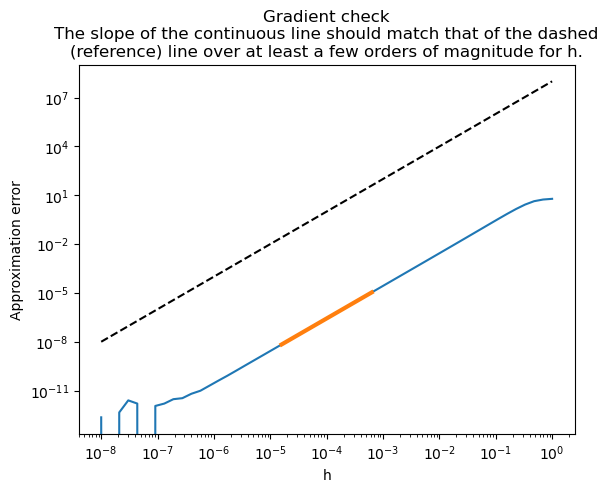

Pymanopt was unable to verify that the gradient is indeed a tangent vector since SpecialOrthogonalProductAnchored does not provide a 'to_tangent_space' implementation.
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +1.2113117803482126e+03    3.65491398e+01    
   2         +1.1822886628115743e+03    2.54641908e+01    
   3         +1.1537690828608747e+03    3.66329289e+01    
   4         +1.1259428550586956e+03    3.19201298e+01    
   5         +1.1196641113047478e+03    4.47356569e+01    
   6         +1.0997153072186450e+03    2.85902748e+01    
   7         +1.0797692086485788e+03    3.97352046e+01    
   8         +1.0616631205757153e+03    2.63667987e+01    
   9         +1.0542067177171043e+03    2.14001168e+01    
  10         +1.0535627554292826e+03    2.80841382e+01    
  11         +1.0512791420576111e+03    2.17252524e+01    
  12         +1.0484036079071857e+03    1.27176098e

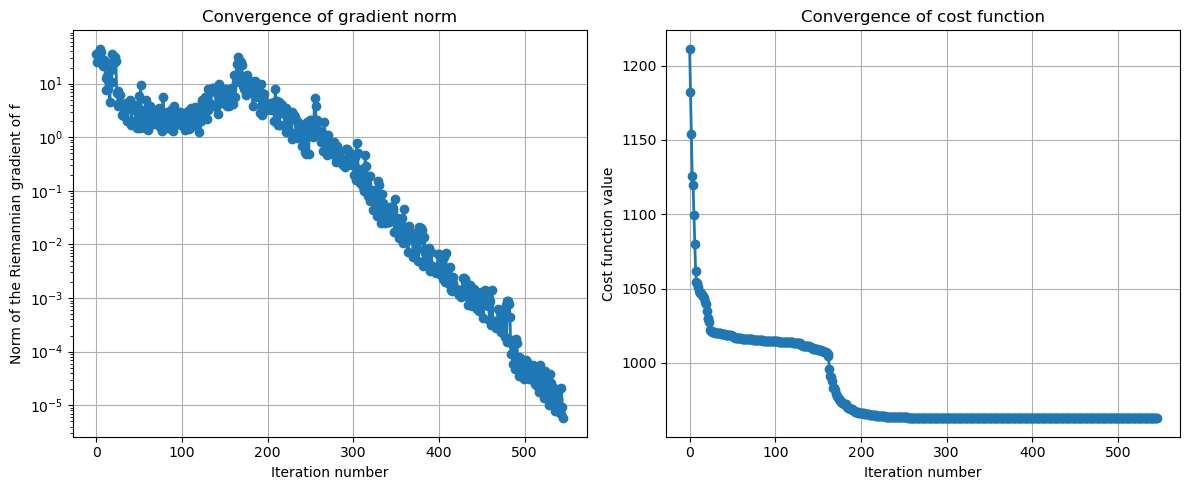

In [17]:
# Question 23 bis
# We try to rerun gradient descent as in Question 16 but this time using the initialisation procedure from Question 23
from pymanopt.optimizers import SteepestDescent
from collections import defaultdict
import numpy as np

raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i) 
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T

deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']

# Compute the initial guess
X0 = initial_guess(deg, m, d, E, H, A, Ra)

# Construct the manifold
manifold = SpecialOrthogonalProductAnchored(d, m, [A], Ra, E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])

# Define the problem
problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

# Solve the problem
check_gradient(problem)

optimizer=optimizers.SteepestDescent(log_verbosity=2)
result=optimizer.run(problem, initial_point = X0)   
grad_norms = optimizer._log["iterations"]["gradient_norm"]
cost_values = optimizer._log["iterations"]["cost"]

# Plot the gradient norm and the cost function value
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function")
plt.grid(True)

plt.tight_layout()
plt.show()